In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
DATA_PATH = "./student_performance_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Dataset Shape: ")

print(df.shape)

Dataset Shape: 
(1000, 12)


In [4]:
print("Dataset Info\n")
df.info()

Dataset Info

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [5]:
# shuffle dataframe and split into train and test sets

shuffled_df = df.sample(frac=1).reset_index(drop=True)

# define columns of interest and create df from it
xs, ys = "study_time_hours", "final_exam_score"
selected_columns = [xs, ys]
selected_df = shuffled_df[selected_columns]

# 80/20 split
split = int(0.8 * len(df)) 

train = selected_df[:split]
print(train.shape)

test = selected_df[split:]
print(test.shape)

(800, 2)
(200, 2)


In [6]:
#initialize gradient descent preparation

slope = random.uniform(1, 100)
bias = random.uniform(1, 100)

print(slope, bias)

57.08152782905142 69.35271202905206


In [7]:
# run gradient descent 20 times

for i in range(20):
    # create predictions array
    preds = train[xs] * slope + bias
    
    # measure error between predictions and actual values
    error = preds - train[ys]
    
    #square the error and sum it to get the loss
    squared_error = error**2
    
    loss = sum(squared_error)
    print(loss)
    
    # math time!
    
    # gradient descent order: loss -> error -> preds -> slope and bias
    
    # derivative of loss wrt. error (step 1)
    dLdE = 2 * error
    
    # derivative of error wrt. preds (step 1.5)
    dEdP = 1
    
    # derivative of loss wrt. preds (step 2)
    dLdP = dLdE * dEdP
    
    # derivative of preds wrt. slope (step 2.5)
    dPdS = train[xs]
    
    # derivative of loss wrt. slope (step 3)
    dLdS = dLdP * dPdS
    slope_grads = dLdS
    
    # derivative of preds wrt. bias (step 3.5)
    dPdB = 1
    
    # derivative of loss wrt. bias (step 4)
    dLdB = dLdP * dPdB
    bias_grads = dLdB
    
    
    # take average of gradients
    
    slope_grad_avg = (sum(slope_grads)) / len(slope_grads)
    
    bias_grad_avg = (sum(bias_grads)) / len(bias_grads)
    
            
    # nudge slope and bias in direction opposite to gradient

    step_size = 0.05
    
    slope -= (slope_grad_avg * step_size)
    
    bias -= (bias_grad_avg * step_size)

33457888.55418561
10769568.14738781
3500846.566986302
1171939.124380038
425553.6194761161
186151.48262841854
109174.15874875098
84239.02865640348
75983.8171652416
73079.68780913543
71897.13546168669
71273.21003046328
70835.1500005911
70463.34341277447
70119.28249188088
69790.44723233268
69472.6482159618
69164.3698313586
68864.95793235306
68574.03910065145


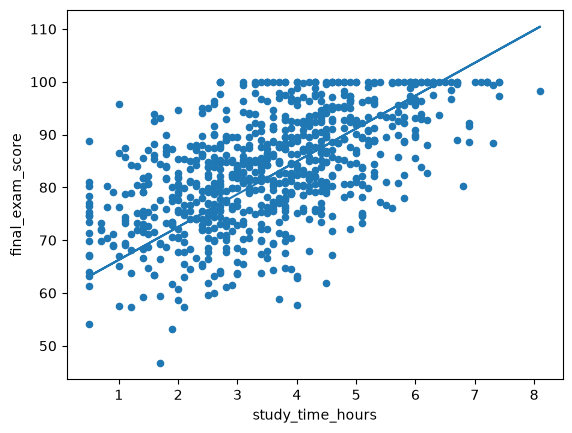

In [8]:
train_graph = train.plot(x=xs, y=ys, kind="scatter")
train_graph.plot(train[xs], preds)

In [9]:
print("The line of best fit takes the shape of", slope)

The line of best fit takes the shape of 6.188921229149773


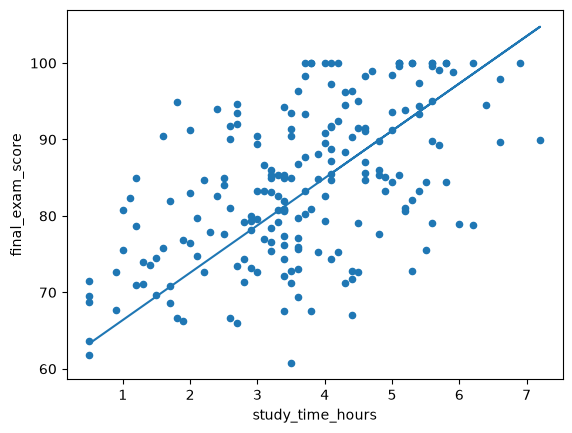

In [10]:
# plot the found slope against the test data
test_graph = test.plot(x=xs, y=ys, kind="scatter")
test_graph.plot(test[xs], test[xs] * slope + bias)